SETUP

In [1]:
import pandas as pd
import numpy as np


In [ ]:
run_id_main = 50412
file_main = f"run/{run_id_main}/results.tsv"

In [3]:
# main dataframe
df = pd.read_csv(file_main, sep='\t', header=0)
df.head()

,id,mode,max_iters,wlhash,stabilized_at,cpu_time_s,max_mem_kib
0,01a7a38902771cf5e7f37b7e0275b0fb,timon,100,2292621771,NaN,5.008370,66776
1,03a1a18521814692f56a8ecbea0031d4,xor,100,4b1a5999a4c34094,NaN,0.223522,0
2,0379936c75c225f1a9a113762b019da6,xor,100,1f566939f3191188,NaN,1.359990,0
3,00316e383123773ae35d3210f5396205,sort,100,00e02c32610c8d66,NaN,0.026124,0
4,03a43a7ea55217f53542ed3f029963af,half,100,9d390429,NaN,0.829233,0


DATA GATHERING

In [4]:
comp = 49696
comp_file = f"run/{comp}/results.tsv"
# main dataframe
df2 = pd.read_csv(comp_file, sep='\t', header=0)

# cleaning (unchanged for wlhash, stabilized_at)
for c in ['wlhash', 'stabilized_at']:
    if c in df2.columns:
        df2[c] = df2[c].replace({'NA': pd.NA, '': pd.NA})

# NEW: ensure numeric types for runtime and memory
for c in ['cpu_time_s', 'max_mem_kib']:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')

# mode (unchanged)
if 'mode' in df2.columns:
    df2['mode'] = pd.Categorical(df2['mode'],
                                 categories=['is2_default','is2_nosort','is2_norehash'],
                                 ordered=True)

# max_iters (unchanged)
if 'max_iters' in df2.columns:
    df2['max_iters'] = pd.to_numeric(df2['max_iters'], errors='coerce').astype('Int64')

# groupings
if 'mode' in df2.columns:
    g = df2.groupby('mode', observed=True)
    per_mode = pd.DataFrame({
        'TOTAL': g.size(),
        'NA': g['wlhash'].apply(lambda x: x.isna().sum()),
        'UNIQUE': g['wlhash'].nunique(dropna=True)
    })
    # SAME = TOTAL - UNIQUE - NA (per mode)
    per_mode['SAME'] = per_mode['TOTAL'] - per_mode['UNIQUE'] - per_mode['NA']

    # NEW: per mode CPU and MEM stats
    if 'cpu_time_s' in df2.columns:
        per_mode['AVG_CPU_S'] = g['cpu_time_s'].mean()
        per_mode['MED_CPU_S'] = g['cpu_time_s'].median()
    if 'max_mem_kib' in df2.columns:
        per_mode['AVG_MEM_KiB'] = g['max_mem_kib'].mean()
        per_mode['MED_MEM_KiB'] = g['max_mem_kib'].median()

    if 'max_iters' in df2.columns:
        g2 = df2.groupby(['mode','max_iters'], observed=True, dropna=False)
        per_mode_iters = pd.DataFrame({
            'TOTAL': g2.size(),
            'NA': g2['wlhash'].apply(lambda x: x.isna().sum()),
            'UNIQUE': g2['wlhash'].nunique(dropna=True)
        })
        # SAME = TOTAL - UNIQUE - NA (per mode, per max_iters)
        per_mode_iters['SAME'] = per_mode_iters['TOTAL'] - per_mode_iters['UNIQUE'] - per_mode_iters['NA']

        # NEW: per mode, per max_iters CPU and MEM stats
        if 'cpu_time_s' in df2.columns:
            per_mode_iters['AVG_CPU_S'] = g2['cpu_time_s'].mean()
            per_mode_iters['MED_CPU_S'] = g2['cpu_time_s'].median()
        if 'max_mem_kib' in df2.columns:
            per_mode_iters['AVG_MEM_KiB'] = g2['max_mem_kib'].mean()
            per_mode_iters['MED_MEM_KiB'] = g2['max_mem_kib'].median()

# Overall metrics (unchanged for wlhash)
total = len(df2)
na = df2['wlhash'].isna().sum()
unique = df2['wlhash'].nunique(dropna=True)
same = total - unique - na

# stabilization (unchanged)
if 'stabilized_at' in df2.columns:
    df2['stabilized_at_num'] = pd.to_numeric(df2['stabilized_at'], errors='coerce')

# avg stabilization (unchanged)
overall_avg_stab = df2['stabilized_at_num'].mean(skipna=True)
if 'mode' in df2.columns:
    per_mode['AVG_STAB'] = g['stabilized_at_num'].mean()
    if 'max_iters' in df2.columns:
        per_mode_iters['AVG_STAB'] = g2['stabilized_at_num'].mean()

# NEW: overall CPU and MEM stats
overall_avg_cpu = df2['cpu_time_s'].mean(skipna=True) if 'cpu_time_s' in df2.columns else None
overall_med_cpu = df2['cpu_time_s'].median(skipna=True) if 'cpu_time_s' in df2.columns else None
overall_avg_mem = df2['max_mem_kib'].mean(skipna=True) if 'max_mem_kib' in df2.columns else None
overall_med_mem = df2['max_mem_kib'].median(skipna=True) if 'max_mem_kib' in df2.columns else None


In [5]:
# prints
print(f"UNIQUE: {unique}")
print(f"NA:     {na}")
print(f"SAME:   {same}")

print(f"\nAVG stabilization point (overall): {overall_avg_stab:.3f}")

# NEW: overall CPU and MEM prints
if overall_avg_cpu is not None:
    print(f"AVG cpu_time_s (overall): {overall_avg_cpu:.3f}")
    print(f"MEDIAN cpu_time_s (overall): {overall_med_cpu:.3f}")
if overall_avg_mem is not None:
    print(f"AVG max_mem_kib (overall): {overall_avg_mem:.1f}")
    print(f"MEDIAN max_mem_kib (overall): {overall_med_mem:.1f}")

# Per-mode breakdown
if 'mode' in df2.columns:
    print("\nBY mode:")
    print(per_mode.to_string())
    if 'max_iters' in df2.columns:
        print("\nBY mode, max_iters:")
        print(per_mode_iters.to_string())


UNIQUE: 2985
NA:     3
SAME:   9

AVG stabilization point (overall): nan
AVG cpu_time_s (overall): 40.711
MEDIAN cpu_time_s (overall): 3.179
AVG max_mem_kib (overall): 133339.9
MEDIAN max_mem_kib (overall): 12544.0

BY mode:
              TOTAL  NA  UNIQUE  SAME  AVG_CPU_S  MED_CPU_S    AVG_MEM_KiB  MED_MEM_KiB  AVG_STAB
mode                                                                                             
is2_default     999   1     995     3  44.629763    3.68423  134047.835836      18200.0       NaN
is2_nosort      999   0     996     3  32.543846    2.60056  131935.807808          0.0       NaN
is2_norehash    999   2     994     3  44.957897    3.69765  134036.180180      19148.0       NaN

BY mode, max_iters:
                        TOTAL  NA  UNIQUE  SAME  AVG_CPU_S  MED_CPU_S    AVG_MEM_KiB  MED_MEM_KiB  AVG_STAB
mode         max_iters                                                                                     
is2_default  100          999   1     995     3 

In [6]:
# --- main dataframe (unchanged) ---
df2 = df.copy()

# --- cleaning ---
for c in ['wlhash', 'stabilized_at']:
    if c in df2.columns:
        df2[c] = df2[c].replace({'NA': pd.NA, '': pd.NA})

for c in ['cpu_time_s', 'max_mem_kib']:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')

# normalize 'mode' text and keep ANY names, preserving first-seen order
if 'mode' in df2.columns:
    df2['mode'] = (
        df2['mode']
        .astype('string')
        .str.strip()
    )
    # order-of-appearance categories (no hard-coding)
    order = pd.unique(df2['mode'].dropna())
    df2['mode'] = pd.Categorical(df2['mode'], categories=order, ordered=True)

# max_iters (unchanged, but safer)
if 'max_iters' in df2.columns:
    df2['max_iters'] = pd.to_numeric(df2['max_iters'], errors='coerce').astype('Int64')

# precompute numeric stabilized_at if present
if 'stabilized_at' in df2.columns:
    df2['stabilized_at_num'] = pd.to_numeric(df2['stabilized_at'], errors='coerce')

# --- groupings ---
per_mode = None
per_mode_iters = None

if 'mode' in df2.columns and 'wlhash' in df2.columns:
    # include NaN as its own group; keep input order (no sorting)
    g = df2.groupby('mode', dropna=False, sort=False, observed=True)

    per_mode = pd.DataFrame({
        'TOTAL': g.size(),
        'NA': g['wlhash'].apply(lambda s: s.isna().sum()),
        'UNIQUE': g['wlhash'].nunique(dropna=True)
    })
    per_mode['SAME'] = per_mode['TOTAL'] - per_mode['UNIQUE'] - per_mode['NA']

    # per-mode CPU/MEM stats (only if cols are present)
    if 'cpu_time_s' in df2.columns:
        per_mode['AVG_CPU_S'] = g['cpu_time_s'].mean()
        per_mode['MED_CPU_S'] = g['cpu_time_s'].median()
    if 'max_mem_kib' in df2.columns:
        per_mode['AVG_MEM_KiB'] = g['max_mem_kib'].mean()
        per_mode['MED_MEM_KiB'] = g['max_mem_kib'].median()
    if 'stabilized_at_num' in df2.columns:
        per_mode['AVG_STAB'] = g['stabilized_at_num'].mean()

    # per mode × max_iters
    if 'max_iters' in df2.columns:
        g2 = df2.groupby(['mode','max_iters'], dropna=False, sort=False, observed=True)
        per_mode_iters = pd.DataFrame({
            'TOTAL': g2.size(),
            'NA': g2['wlhash'].apply(lambda s: s.isna().sum()),
            'UNIQUE': g2['wlhash'].nunique(dropna=True)
        })
        per_mode_iters['SAME'] = per_mode_iters['TOTAL'] - per_mode_iters['UNIQUE'] - per_mode_iters['NA']

        if 'cpu_time_s' in df2.columns:
            per_mode_iters['AVG_CPU_S'] = g2['cpu_time_s'].mean()
            per_mode_iters['MED_CPU_S'] = g2['cpu_time_s'].median()
        if 'max_mem_kib' in df2.columns:
            per_mode_iters['AVG_MEM_KiB'] = g2['max_mem_kib'].mean()
            per_mode_iters['MED_MEM_KiB'] = g2['max_mem_kib'].median()
        if 'stabilized_at_num' in df2.columns:
            per_mode_iters['AVG_STAB'] = g2['stabilized_at_num'].mean()

# --- overall metrics (guarded) ---
total = len(df2)
if 'wlhash' in df2.columns:
    na = df2['wlhash'].isna().sum()
    unique = df2['wlhash'].nunique(dropna=True)
    same = total - unique - na
else:
    na = unique = same = None

overall_avg_stab = df2['stabilized_at_num'].mean(skipna=True) if 'stabilized_at_num' in df2.columns else None

overall_avg_cpu = df2['cpu_time_s'].mean(skipna=True) if 'cpu_time_s' in df2.columns else None
overall_med_cpu = df2['cpu_time_s'].median(skipna=True) if 'cpu_time_s' in df2.columns else None
overall_avg_mem = df2['max_mem_kib'].mean(skipna=True) if 'max_mem_kib' in df2.columns else None
overall_med_mem = df2['max_mem_kib'].median(skipna=True) if 'max_mem_kib' in df2.columns else None


PRINTING

In [7]:
# prints
print(f"UNIQUE: {unique}")
print(f"NA:     {na}")
print(f"SAME:   {same}")

print(f"\nAVG stabilization point (overall): {overall_avg_stab:.3f}")

# NEW: overall CPU and MEM prints
if overall_avg_cpu is not None:
    print(f"AVG cpu_time_s (overall): {overall_avg_cpu:.3f}")
    print(f"MEDIAN cpu_time_s (overall): {overall_med_cpu:.3f}")
if overall_avg_mem is not None:
    print(f"AVG max_mem_kib (overall): {overall_avg_mem:.1f}")
    print(f"MEDIAN max_mem_kib (overall): {overall_med_mem:.1f}")

# Per-mode breakdown
if 'mode' in df2.columns:
    print("\nBY mode:")
    print(per_mode.to_string())
    if 'max_iters' in df2.columns:
        print("\nBY mode, max_iters:")
        print(per_mode_iters.to_string())


UNIQUE: 3925
NA:     0
SAME:   71

AVG stabilization point (overall): nan
AVG cpu_time_s (overall): 39.748
MEDIAN cpu_time_s (overall): 2.751
AVG max_mem_kib (overall): 132277.8
MEDIAN max_mem_kib (overall): 0.0

BY mode:
       TOTAL  NA  UNIQUE  SAME  AVG_CPU_S  MED_CPU_S    AVG_MEM_KiB  MED_MEM_KiB  AVG_STAB
mode                                                                                      
timon    999   0     996     3  33.413344    2.72088  133241.685686          0.0       NaN
xor      999   0     937    62  28.946166    2.45267  131992.732733          0.0       NaN
sort     999   0     996     3  54.964326    4.24707  134759.875876      22156.0       NaN
half     999   0     996     3  41.667803    2.31094  129116.708709          0.0       NaN

BY mode, max_iters:
                 TOTAL  NA  UNIQUE  SAME  AVG_CPU_S  MED_CPU_S    AVG_MEM_KiB  MED_MEM_KiB  AVG_STAB
mode  max_iters                                                                                     
timon 100

PLOTS

In [8]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

**Analyzing Positives**

FAMILIES

In [9]:
# CELL 1 — Prep once: filter, clean, scope to mode=none and wlhash appearing > 1 time

df1 = df.copy()

# filter and clean
df1 = df1[df1['mode'] == 'none'].copy()
df1['wlhash'] = df1['wlhash'].replace({'NA': pd.NA, '': pd.NA})
df1['family'] = df1['family'].replace({'': pd.NA})

# rows with valid wlhash
_valid = df1[['wlhash', 'family']].dropna(subset=['wlhash'])

# restrict to wlhash that appear more than once
_dups = _valid['wlhash'].value_counts()
dup_rows = _valid[_valid['wlhash'].isin(_dups[_dups > 1].index)].copy()

# helpers reused by later cells
def _famcounts_str(s):
    vals = s.dropna().astype(str).str.strip()
    pairs = sorted(vals.value_counts().items(), key=lambda kv: (-kv[1], kv[0]))
    return ', '.join(f'{k}:{v}' for k, v in pairs)

def _famset_sorted(s):
    return sorted({x for x in s.dropna().astype(str).str.strip() if x})

def _combo_label(fam_list):
    return ' + '.join(fam_list)


KeyError: 'family'

In [ ]:
# CELL 2 — Per-wlhash details: totals and per-family counts (only wlhash with >1 family)

g = dup_rows.groupby('wlhash', observed=True)
per_wlhash = (
    pd.DataFrame({
        'total_instances': g.size(),
        'num_families': g['family'].nunique(dropna=True),
        'families': g['family'].apply(lambda s: ', '.join(_famset_sorted(s))),
        'family_counts': g['family'].apply(_famcounts_str),
    })
    .reset_index()
)

per_wlhash = per_wlhash[per_wlhash['num_families'] > 1].sort_values(
    ['num_families', 'total_instances', 'wlhash'], ascending=[False, False, True]
)

print(f"{len(per_wlhash)} wlhash values with multiple families in mode=none")
display(per_wlhash)

18 wlhash values with multiple families in mode=none


,wlhash,total_instances,num_families,families,family_counts
262,45f3bc1ced651cad,20,2,"graph-based, tseitin-formulas","tseitin-formulas:18, graph-based:2"
588,a5ce118e1f864f07,6,2,"miter, xor-chain","miter:5, xor-chain:1"
38,08f753fdfe927a42,5,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:2"
449,7e23de98201a1c06,5,2,"graph-based, tseitin-formulas","graph-based:3, tseitin-formulas:2"
635,b0ea13cac65b6016,5,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:2"
661,b7a5ac965a880dbc,5,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:2"
68,11fbe957eed4e935,4,2,"cryptography, software-verification","cryptography:2, software-verification:2"
410,746ba6407ff55b46,4,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:1"
618,ada1aa02b5ab1be9,4,2,"philips, unknown","philips:3, unknown:1"
692,bf1a9f23f6bf2347,4,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:1"


In [ ]:
# CELL 3 — Group by family combination across wlhash

g2 = dup_rows.groupby('wlhash', observed=True)
per_hash_combo = (
    g2['family'].agg(
        families=lambda s: _famset_sorted(s),
        total_instances='size'
    ).reset_index()
)
per_hash_combo['num_families'] = per_hash_combo['families'].apply(len)
per_hash_combo = per_hash_combo[per_hash_combo['num_families'] > 1].copy()
per_hash_combo['family_combo'] = per_hash_combo['families'].apply(_combo_label)

combo_summary = (
    per_hash_combo.groupby(['family_combo', 'num_families'], observed=True)
    .agg(
        wlhash_count=('wlhash', 'nunique'),
        instances_count=('total_instances', 'sum'),
    )
    .reset_index()
    .sort_values(['wlhash_count', 'instances_count', 'num_families', 'family_combo'],
                 ascending=[False, False, False, True])
)

print(f"{len(combo_summary)} family combinations with multiple families (mode=none)")
display(combo_summary)


7 family combinations with multiple families (mode=none)


,family_combo,num_families,wlhash_count,instances_count
4,graph-based + tseitin-formulas,2,10,56
2,cryptography + software-verification,2,3,10
5,miter + xor-chain,2,1,6
6,philips + unknown,2,1,4
1,coloring + mycielski-graph,2,1,3
0,clique-colouring + coloring,2,1,2
3,dining-philosophers + misc-satex,2,1,2


In [ ]:
# CELL 4 — Per-family summary: unique wlhash count and total instances (singular family view)

per_family = (
    dup_rows.dropna(subset=['family'])
    .groupby('family', observed=True)['wlhash']
    .agg(wlhash_count='nunique', instances_count='size')
    .reset_index()
    .sort_values(['wlhash_count', 'instances_count', 'family'], ascending=[False, False, True])
)

print(f"{len(per_family)} families in mode=none (within wlhash that appear >1 time)")
display(per_family)


79 families in mode=none (within wlhash that appear >1 time)


,family,wlhash_count,instances_count
29,hardware-verification,109,276
46,planning,99,220
12,coloring,56,351
37,miter,52,163
14,cryptography,51,116
...,...,...,...
60,random-mus,1,2
63,relativized-pigeon-hole,1,2
70,stedman-triples,1,2
71,stone,1,2


**Hash Behaviour Plots**


In [ ]:
# identifying all instances that got wlhash by both modes sum and none
# Hashes that have a non-null wlhash in BOTH modes 'none' and 'sum'

t = df2[(df2['mode'].isin(['is2_default', 'is2_nosort', 'is2_norehash'])) & (df2['wlhash'].notna())].copy()
wide = t.groupby(['id', 'mode'])['wlhash'].first().unstack()  # one wlhash per (hash, mode)
both = (
    wide.dropna(subset=['is2_default', 'is2_nosort', 'is2_norehash'])
        .reset_index()
        .rename(columns={'is2_default': 'default', 'is2_nosort': 'no_sort', 'is2_norehash': 'no_rehash'})
)

print(f"{len(both)} hashes with wlhash in both modes")
display(both)

996 hashes with wlhash in both modes


/tmp/ipykernel_2327102/1071019044.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wide = t.groupby(['id', 'mode'])['wlhash'].first().unstack()  # one wlhash per (hash, mode)


mode,id,default,no_sort,no_rehash
0,00063d88244921d6ec46aeab6866a8e2,6.004429e+08,1.102934e+09,9.264072e+08
1,00072cf107ae1349c8c59a15c5ce4af1,3.690513e+09,2.993933e+09,1.668537e+09
2,00076733bdbce94d7e44eca84f1425f0,4.067154e+09,2.626123e+07,1.503507e+09
3,000781b7a545fe723159e53127aff659,2.590156e+08,3.248099e+09,3.234076e+09
4,000a41cdca43be89ed62ea3abf2d0b64,3.774839e+09,4.124904e+09,2.395550e+09
...,...,...,...,...
991,089c0775c15f15ad5810c69bab91f31d,1.173879e+09,1.532084e+09,4.178919e+07
992,089ec06b35d6d5c89f2e47cf030aff36,3.758464e+09,4.937716e+08,3.186400e+09
993,089f909e37b3ef0c4d90687f7e22b68f,2.319882e+09,3.984458e+09,1.390837e+09
994,089fb3a9b41e13d30852e8b023e39ed7,1.478206e+09,1.359170e+09,2.908543e+09


/tmp/ipykernel_2327102/4191770792.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sel.groupby('mode')['cpu_time_s']


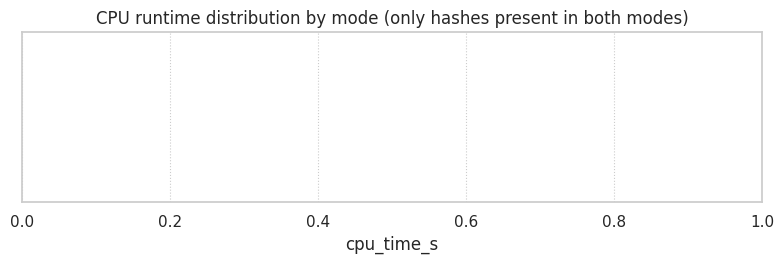

In [ ]:
# comparing cpu runtime of modes sum vs none via min,1/4,mean,3/4,max horizontal stick plot, over each other

# select hashes that have wlhash in both modes
t = df2[(df2['mode'].isin(['is2_default', 'is2_nosort', 'is2_norehash'])) & (df2['wlhash'].notna())].copy()
both_hashes = t.groupby('id')['mode'].nunique()
both_hashes = both_hashes[both_hashes == 2].index
sel = t[t['id'].isin(both_hashes)].copy()

# numeric cpu time
sel['cpu_time_s'] = pd.to_numeric(sel['cpu_time_s'], errors='coerce')
sel = sel.dropna(subset=['cpu_time_s'])

# summarize per mode
def _q1(s): return s.quantile(0.25)
def _q3(s): return s.quantile(0.75)

stats_df = (
    sel.groupby('mode')['cpu_time_s']
      .agg(min='min', q1=_q1, mean='mean', q3=_q3, max='max')
      .reindex(['none','sum'])
      .dropna(how='all')
)

# plot
fig, ax = plt.subplots(figsize=(8, 2.8))
yticks, ylabels = [], []
for i, (mode, row) in enumerate(stats_df.iterrows()):
    y = i
    yticks.append(y); ylabels.append(mode)
    # whisker: min..max
    ax.hlines(y=y, xmin=row['min'], xmax=row['max'], linewidth=2)
    # IQR bar: q1..q3
    ax.hlines(y=y, xmin=row['q1'], xmax=row['q3'], linewidth=8)
    # mean marker
    ax.plot(row['mean'], y, marker='o')

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_xlabel('cpu_time_s')
ax.set_title('CPU runtime distribution by mode (only hashes present in both modes)')
ax.grid(True, axis='x', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()


In [ ]:
sns.lineplot(data=avg, x='max_iters', y='unique', hue='mode', marker='o')
plt.title('Unique Hashes by iteration limit')
plt.xlabel('max_iters'); plt.ylabel('unique hashes')
plt.show()


NameError: name 'avg' is not defined

In [ ]:
sns.lineplot(data=avg, x='max_iters', y='same', hue='mode', marker='o')
plt.title('Same Hashes by iteration limit')
plt.xlabel('max_iters'); plt.ylabel('same hashes')
plt.show()

NameError: name 'avg' is not defined

In [ ]:
sns.lineplot(data=avg, x='max_iters', y='na', hue='mode', marker='o')
plt.title('NA Hashes by iteration limit')
plt.xlabel('max_iters'); plt.ylabel('NA hashes')
plt.show()

In [ ]:
# --- minimal prep (safe to rerun) ---
hash_col = 'hash' if 'hash' in df.columns else 'isohash'
df2 = df.copy()
df2[hash_col]      = df2[hash_col].replace({'NA': pd.NA})
df2['cpu_time_s']  = pd.to_numeric(df2.get('cpu_time_s'),  errors='coerce')
df2['max_mem_kib'] = pd.to_numeric(df2.get('max_mem_kib'), errors='coerce')
if 'mode' in df2.columns:
    df2['mode'] = pd.Categorical(df2['mode'], categories=['raw','canon'], ordered=True)

# --- label each row as unique vs same within (max_iters, mode) ---
counts = (
    df2.groupby(['max_iters','mode'])[hash_col]
       .transform(lambda s: s.map(s.value_counts(dropna=True)))
)
df2['hash_status'] = np.where(
    df2[hash_col].isna(), 'na',
    np.where(counts == 1, 'unique', 'same')
)

# drop NA-hash rows for this comparison
df3 = df2[df2['hash_status'] != 'na'].copy()

# --- averages by iteration, mode, and uniqueness ---
summary = (df3
    .groupby(['max_iters','mode','hash_status'], as_index=False)
    .agg(avg_cpu_s=('cpu_time_s','mean'),
         avg_mem_kib=('max_mem_kib','mean'),
         n=('hash_status','size'))
    .sort_values(['max_iters','mode','hash_status'])
)
# nice numeric dtype for x-axis
summary['max_iters'] = pd.to_numeric(summary['max_iters'], errors='coerce').astype('Int64')

# ---- lineplots ----
# CPU time
sns.lineplot(
    data=summary,
    x='max_iters', y='avg_cpu_s',
    hue='hash_status', style='mode', marker='o'
)
plt.title('Avg CPU time by iteration, split by unique vs same')
plt.xlabel('max_iters'); plt.ylabel('seconds')
plt.show()

# Memory
sns.lineplot(
    data=summary,
    x='max_iters', y='avg_mem_kib',
    hue='hash_status', style='mode', marker='o'
)
plt.title('Avg memory by iteration, split by unique vs same')
plt.xlabel('max_iters'); plt.ylabel('KiB')
plt.show()

KeyError: 'max_iters'

**Performance Plots** (CPU, Memory)

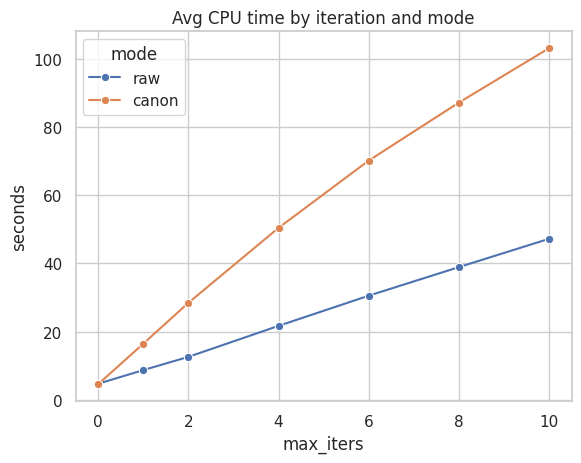

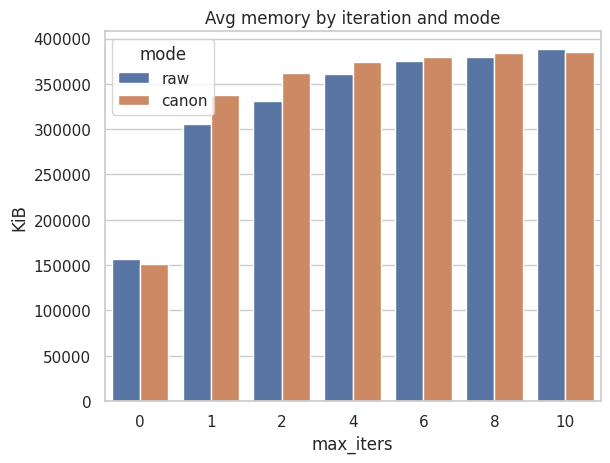

In [ ]:
sns.lineplot(data=avg, x='max_iters', y='avg_cpu_s', hue='mode', marker='o')
plt.title('Avg CPU time by iteration and mode')
plt.xlabel('max_iters'); plt.ylabel('seconds')
plt.show()

sns.barplot(data=avg, x='max_iters', y='avg_mem_kib', hue='mode')
plt.title('Avg memory by iteration and mode'); plt.xlabel('max_iters'); plt.ylabel('KiB')
plt.show()


GET ALL DUPLICATE HASHES AND THEIR INSTANCES

In [ ]:
# adding isohash to duplicated hashes of main to compare
dupe_rows = df[df['hash'].duplicated(keep=False)].sort_values('hash')
merged = dupe_rows.merge(
    df_comp[['ID','isohash']],
    on='ID',
    how='left'
)
print(merged.head(10))

NameError: name 'df_comp' is not defined

In [ ]:
# adding hash of main to duplicated hashes of isohash
dupe_rows_comp = df_comp[df_comp['isohash'].duplicated(keep=False)].sort_values('isohash')
merged = dupe_rows_comp.merge(
    df[['ID','hash']],
    on='ID',
    how='left'
)
print(merged.head(10))

                                 ID                           isohash  \
0  4666906deb05406c0ecc18de81673d76  00a1a353e84e203de503f206c02b7a2c   
1  4666906deb05406c0ecc18de81673d76  00a1a353e84e203de503f206c02b7a2c   
2  ae07d3502702cd744ad48e254abb192f  00a1a353e84e203de503f206c02b7a2c   
3  ae07d3502702cd744ad48e254abb192f  00a1a353e84e203de503f206c02b7a2c   
4  74acaa627ddc5fdab40d62172f56a827  00c5b384d9311d83da0be53e990b4904   
5  74acaa627ddc5fdab40d62172f56a827  00c5b384d9311d83da0be53e990b4904   
6  66ab346df72c5effa292342037bc3909  00c5b384d9311d83da0be53e990b4904   
7  66ab346df72c5effa292342037bc3909  00c5b384d9311d83da0be53e990b4904   
8  df3da7a967605e804571a36c099416b7  00efc6678bd4710b52c3448cc6e9c5da   
9  df3da7a967605e804571a36c099416b7  00efc6678bd4710b52c3448cc6e9c5da   

               hash  
0  cc59bf95d464f26e  
1  a92e9acdee3d7306  
2  cc59bf95d464f26e  
3  a92e9acdee3d7306  
4  28a3415cc12d2e15  
5  d113037ad7d90966  
6  28a3415cc12d2e15  
7  d113037ad7d90966 